## Algoritmo A* per Mappa Droni

## Import

In [3]:
import heapq
import numpy as np
import matplotlib.pyplot as plt

## Classe Node

In [ ]:
class Node:
    def __init__(self, state, parent=None, g=0, h=0):
        self.state = state
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h

    def __lt__(self, other):   #lt= less then ovvero prima il minore
        return self.f < other.f

## Funzioni di Utilità

In [ ]:
# -----------------------------
# Funzione Euristica (Distanza di Manhattan)
# -----------------------------

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# -----------------------------
# Funzione Successori
# -----------------------------

def get_neighbors(state, grid):

    moves = [(1,0),(-1,0),(0,1),(0,-1)]

    neighbors = []

    for dx,dy in moves:

        nx = state[0] + dx
        ny = state[1] + dy

        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx,ny] != 1:
                neighbors.append((nx,ny))

    return neighbors


# -----------------------------
# Ricostruzione del Percorso
# -----------------------------

def reconstruct(node):

    path = []

    while node:
        path.append(node.state)
        node = node.parent

    return path[::-1]    #per invertire la lista dato che stiamo andando al contrario, i due punti vuol dire che prendo tutta la lista, inizio lista: fino alla fine della lista: , -1 sarebbe il passo ovvero la percorre partendo dalla fine


## Algoritmo A*

In [ ]:
def astar(grid, start, goal):

    frontiera = []
    heapq.heappush(frontiera, Node(start, None, 0, heuristic(start, goal)))  #heappush aggiunge un elemento con una logica di priorità che abbiamo stabilito all'inizio in lt, less then

    # INSERISCI QUI IL TUO CODICE
    closed = set()   #con set tengo traccia delle posizioni gia analizzate, non accetta duplicati, ordine in cui si inserisce, non si puo accedere in modo ordinato perchè tanto ci interessa solo se è gia visitato

    while frontiera:

        current = heapq.heappop(frontiera) #heappop estrae il piu piccolo in questo caso e poi riorganizza con il nuovo piu piccolo

        if current.state == goal:
            # INSERISCI QUI IL TUO CODICE
            return reconstruct(current)    #se è lo stato goal ricostruisce il percorso

        closed.add(current.state)   #segniamo lo stato corrente come visitato

        for n in get_neighbors(current.state, grid):

            if n in closed:
                # INSERISCI QUI IL TUO CODICE
                continue  #ignora lo stato n che sta in closed

            g = current.g + 1     #lunghezza effettiva del percorso fino ad ora, costo=1 gia predefinito
            
            # INSERISCI QUI IL TUO CODICE
            h = heuristic(n,goal)   #previsione di quanto manca al traguardo

            heapq.heappush(frontiera, Node(n, current, g, h))  #heappush aggiunge un elemento con una logica di priorità, start=n , current è il nodo genitore

    return None

## Generazione Mappa

In [ ]:
# -----------------------------
# Map generation
# -----------------------------

def create_map():

    grid = np.zeros((30,30))

    # no-fly zones
    grid[5:12, 10:15] = 1
    grid[15:20, 3:10] = 1  #dalla 15 alla 20 nelle x, dalla 3 alla 10 nelle y
    grid[10:18, 20:25] = 1
    grid[22:27, 12:18] = 1

    return grid


## Visualizzazione

In [13]:
def plot_map(grid, path, start, goal):

    plt.figure(figsize=(8,8))

    plt.imshow(grid, cmap="gray_r")

    if path:
        px = [p[1] for p in path]
        py = [p[0] for p in path]
        plt.plot(px, py, linewidth=3)

    plt.scatter(start[1], start[0], marker="o", s=200)
    plt.scatter(goal[1], goal[0], marker="x", s=200)

    plt.title('Pianificazione del percorso del Drone con A*')
    plt.grid(True)

    plt.show()

## Esecuzione

Lunghezza del percorso: 59


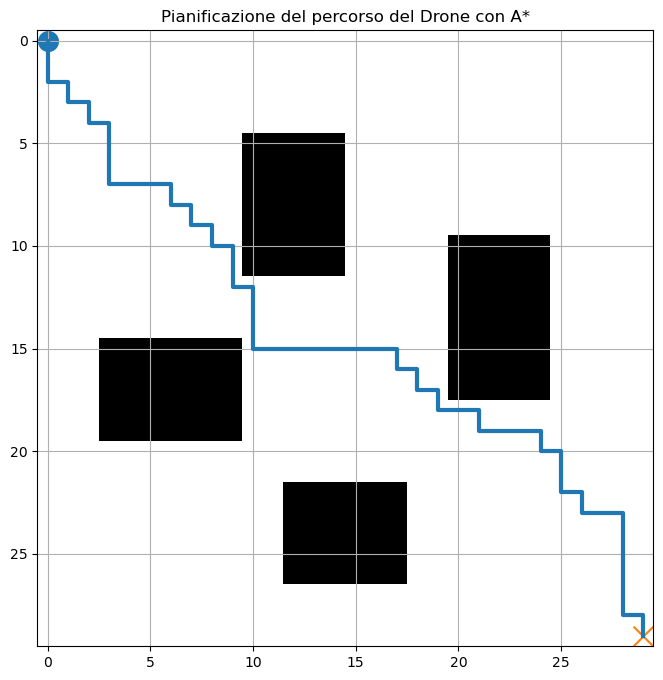

In [15]:
# -----------------------------
# Main simulation
# -----------------------------

grid = create_map()

start = (0,0)
goal = (29,29)

path = astar(grid, start, goal)

print('Lunghezza del percorso:', len(path))

plot_map(grid, path, start, goal)